In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Importación de Datos y Renombrado


In [44]:
df = pd.read_csv('../datos/originales/credit_risk_dataset.csv')
df.rename(columns={
    'person_age': 'edad',
    'person_income': 'ingreso',
    'person_home_ownership': 'propiedad_vivienda',
    'person_emp_length': 'duracion_empleo',
    'loan_intent': 'intencion_prestamo',
    'loan_grade': 'calificacion_prestamo',
    'loan_amnt': 'monto_prestamo',
    'loan_int_rate': 'tasa_interes',
    'loan_status': 'estado_prestamo',
    'loan_percent_income': 'porcentaje_ingreso',
    'cb_person_default_on_file': 'incumplimiento_historial',
    'cb_person_cred_hist_length': 'duracion_credito'
}, inplace=True)

In [45]:
df.head()

,edad,ingreso,propiedad_vivienda,duracion_empleo,intencion_prestamo,calificacion_prestamo,monto_prestamo,tasa_interes,estado_prestamo,porcentaje_ingreso,incumplimiento_historial,duracion_credito
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Tipos de Datos

Los tipos de datos están correctos.

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   edad                      32581 non-null  int64  
 1   ingreso                   32581 non-null  int64  
 2   propiedad_vivienda        32581 non-null  object 
 3   duracion_empleo           31686 non-null  float64
 4   intencion_prestamo        32581 non-null  object 
 5   calificacion_prestamo     32581 non-null  object 
 6   monto_prestamo            32581 non-null  int64  
 7   tasa_interes              29465 non-null  float64
 8   estado_prestamo           32581 non-null  int64  
 9   porcentaje_ingreso        32581 non-null  float64
 10  incumplimiento_historial  32581 non-null  object 
 11  duracion_credito          32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


### Análisis de Unicos
No se encontraron variables constantes.

In [47]:
df.nunique().sort_values()

incumplimiento_historial       2
estado_prestamo                2
propiedad_vivienda             4
intencion_prestamo             6
calificacion_prestamo          7
duracion_credito              29
duracion_empleo               36
edad                          58
porcentaje_ingreso            77
tasa_interes                 348
monto_prestamo               753
ingreso                     4295
dtype: int64

### Registros Duplicados

Se han eliminado los registros duplicados del dataset, ya que no aportan información nueva al modelo.

In [48]:
df.duplicated().sum()

np.int64(165)

In [49]:
df.drop_duplicates(inplace=True)

### Análisis de Variables Categóricas

No se encontraron nulos ni categorías raras.

In [50]:
cat = df.select_dtypes(exclude='number').copy()

In [51]:
cat.isna().sum()

propiedad_vivienda          0
intencion_prestamo          0
calificacion_prestamo       0
incumplimiento_historial    0
dtype: int64

In [52]:
for variable in cat:
    print(cat[variable].value_counts())
    print('\n\n')

propiedad_vivienda
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64



intencion_prestamo
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64



calificacion_prestamo
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64



incumplimiento_historial
N    26686
Y     5730
Name: count, dtype: int64





### Análisis de Variables Numéricas

In [53]:
num = df.select_dtypes(include='number').copy()

In [54]:
num.describe().T

,count,mean,std,min,25%,50%,75%,max
edad,32416.0,27.747008,6.354100,20.00,23.00,26.00,30.00,144.00
ingreso,32416.0,66091.640826,62015.580269,4000.00,38542.00,55000.00,79218.00,6000000.00
duracion_empleo,31529.0,4.790510,4.145490,0.00,2.00,4.00,7.00,123.00
monto_prestamo,32416.0,9593.845632,6322.730241,500.00,5000.00,8000.00,12250.00,35000.00
tasa_interes,29321.0,11.017265,3.241680,5.42,7.90,10.99,13.47,23.22
estado_prestamo,32416.0,0.218688,0.413363,0.00,0.00,0.00,0.00,1.00
porcentaje_ingreso,32416.0,0.170250,0.106812,0.00,0.09,0.15,0.23,0.83
duracion_credito,32416.0,5.811297,4.059030,2.00,3.00,4.00,8.00,30.00


#### Nulos
Se detecta y eliminan los nulos.

In [55]:
num.isna().sum()

edad                     0
ingreso                  0
duracion_empleo        887
monto_prestamo           0
tasa_interes          3095
estado_prestamo          0
porcentaje_ingreso       0
duracion_credito         0
dtype: int64

In [56]:

nulos = num[num.isna().any(axis=1)].index

num = num.dropna()
cat = cat.drop(nulos)
df = df.drop(nulos)

#### Valores Atípicos

In [57]:
def atipicos_desv_tip(variable, num_desv_tip = 4):
    #sacamos los nulos por ahora
    variable = variable.dropna()
    #calculamos los límites
    media = np.mean(variable)
    sd = np.std(variable)
    umbral = sd * num_desv_tip
    lim_inf = media - umbral
    lim_sup = media + umbral
    #encontramos los índices de los que están fuera de los límites
    indices = [indice for indice,valor in variable.items() if valor < lim_inf or valor > lim_sup]
    return(indices)

def conteo_atipicos(df,variable, num_desv_tip = 4):
    atipicos = atipicos_desv_tip(df[variable], num_desv_tip)
    return(df.loc[atipicos,variable].value_counts().sort_index())

In [58]:
for variable in num.columns:
    print(conteo_atipicos(num, variable , 4))

edad
54     21
55     18
56     14
57     15
58     17
59      5
60     13
61      8
62      6
63      3
64      7
65      5
66      8
67      1
69      5
70      5
73      2
76      1
78      1
80      1
84      1
123     1
144     3
Name: count, dtype: int64
ingreso
320000     2
325000     3
325550     1
330000     1
334000     1
          ..
1362000    1
1440000    1
1782000    1
2039784    1
6000000    1
Name: count, Length: 66, dtype: int64
duracion_empleo
22.0     18
23.0     10
24.0      8
25.0      8
26.0      4
27.0      5
28.0      2
29.0      1
30.0      2
31.0      4
34.0      1
38.0      1
41.0      1
123.0     2
Name: count, dtype: int64
monto_prestamo
35000    156
Name: count, dtype: int64
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
porcentaje_ingreso
0.60     8
0.61     3
0.62     1
0.63    10
0.64     5
0.65     3
0.66     1
0.67     4
0.68     3
0.69     2
0.70     3
0.71     3
0.72     1
0.76     1
0.77     2
0.78     1
0.83     1
Name

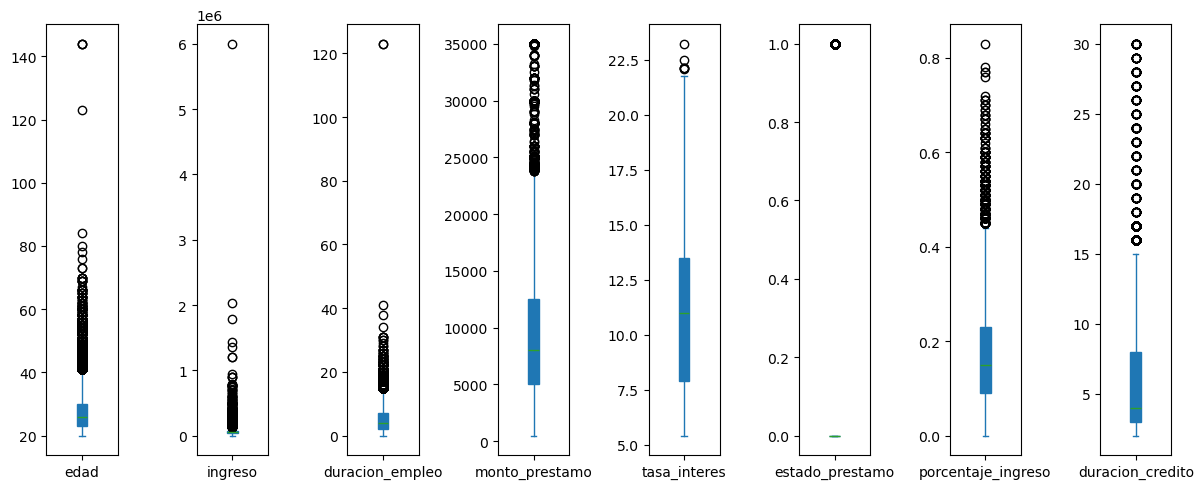

In [59]:
num.plot(kind='box', subplots=True, figsize=(12, 5), patch_artist=True)

plt.tight_layout()
plt.show()

Se identifican registros con valores atipicos por lo que se establece los cortes:
- Edad mayor a 90 años
- Duración de empleo mayor a 50 años

In [60]:
index = num[(num.edad > 90) | (num.duracion_empleo > 50)].index

In [61]:
num = num.drop(index)
cat = cat.drop(index)
df = df.drop(index)

### Exploración de datos

In [62]:
df.to_pickle("../datos/entrenamiento/train_resultado_calidad.pkl")
cat.to_pickle("../datos/entrenamiento/cat_resultado_calidad.pkl")
num.to_pickle("../datos/entrenamiento/num_resultado_calidad.pkl")